# Promotion Features — Step 3B

Build promotion / display / mailer features from dunnhumby `causal_data.csv` and merge onto the weekly feature tables from `01_feature_engineering.ipynb`.


### Cell 1 — Setup

Load existing feature tables (from notebook 01) and explore the raw causal_data file. This notebook adds promotional features to the existing feature tables.


In [85]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("../..").resolve()
DATA_RAW_DH = PROJECT_ROOT / "data" / "raw" / "dunnhumby"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

pd.set_option("display.max_columns", 30)

# Load existing feature tables we'll be joining promotional features into
dense_features = pd.read_parquet(DATA_INTERIM / "features_dense.parquet")
chain_features = pd.read_parquet(DATA_INTERIM / "features_chain.parquet")

# Load perishable product master (we need this to filter causal_data)
perishable_products = pd.read_parquet(DATA_INTERIM / "perishable_products.parquet")
perishable_ids = set(perishable_products["PRODUCT_ID"])

print(f"Dense features:  {len(dense_features):,} rows")
print(f"Chain features:  {len(chain_features):,} rows")
print(f"Perishable SKUs: {len(perishable_ids):,}")
print(f"\nCausal data file size: {(DATA_RAW_DH / 'causal_data.csv').stat().st_size / 1e9:.2f} GB")


Dense features:  15,694 rows
Chain features:  76 rows
Perishable SKUs: 14,148

Causal data file size: 0.70 GB


### Cell 2 — Explore causal_data structure

Read a sample of the 696 MB file to understand its columns and values before processing the full file.

**Columns:** `PRODUCT_ID`, `STORE_ID`, `WEEK_NO`, `display`, `mailer` (single-character dunnhumby codes).

**Feature strategy (collapsed, not 17-way one-hot):** for each (store, category, week) compute `pct_skus_on_display`, `pct_skus_on_mailer`, `pct_skus_front_page` (mailer D or H = front-page prominence).

**Display:** 0=none; 1–7,9,A = location types (end cap, aisle, shelf, etc.). **Mailer:** 0=none; A/C/D/F/H/J = interior, line, front, back, wrap features.


In [86]:
# Read only first 100K rows for structure exploration
causal_sample = pd.read_csv(DATA_RAW_DH / "causal_data.csv", nrows=100_000)

print(f"Sample shape: {causal_sample.shape}")
print(f"Columns: {causal_sample.columns.tolist()}")
print(f"\nData types:")
print(causal_sample.dtypes.to_string())
print(f"\nFirst 10 rows:")
print(causal_sample.head(10).to_string())
print(f"\nUnique values per column:")
for col in causal_sample.columns:
    n_unique = causal_sample[col].nunique()
    if n_unique < 30:
        print(f"  {col}: {sorted(causal_sample[col].unique())}")
    else:
        print(f"  {col}: {n_unique:,} unique values")


Sample shape: (100000, 5)
Columns: ['PRODUCT_ID', 'STORE_ID', 'WEEK_NO', 'display', 'mailer']

Data types:
PRODUCT_ID     int64
STORE_ID       int64
WEEK_NO        int64
display       object
mailer        object

First 10 rows:
   PRODUCT_ID  STORE_ID  WEEK_NO display mailer
0       26190       286       70       0      A
1       26190       288       70       0      A
2       26190       289       70       0      A
3       26190       292       70       0      A
4       26190       293       70       0      A
5       26190       295       70       0      A
6       26190       296       70       0      A
7       26190       297       70       0      A
8       26190       298       70       0      A
9       26190       299       70       0      A

Unique values per column:
  PRODUCT_ID: 89 unique values
  STORE_ID: 115 unique values
  WEEK_NO: 93 unique values
  display: ['0', '1', '2', '3', '4', '5', '6', '7', '9', 'A']
  mailer: ['0', 'A', 'C', 'D', 'F', 'H', 'J']


### Cell 3 — Load full causal_data, filtered to perishable products

696 MB file, but most rows are for non-perishable products. Stream in chunks and keep only rows where PRODUCT_ID is in our perishable set.

In [87]:
CHUNK_SIZE = 500_000
causal_chunks = []
total_rows = 0

print("Streaming causal_data and filtering to perishables...")
print("=" * 60)

reader = pd.read_csv(
    DATA_RAW_DH / "causal_data.csv",
    dtype={"PRODUCT_ID": "int64", "STORE_ID": "int64", "WEEK_NO": "int32",
           "display": "category", "mailer": "category"},
    chunksize=CHUNK_SIZE,
)

for i, chunk in enumerate(reader):
    total_rows += len(chunk)
    perishable_chunk = chunk[chunk["PRODUCT_ID"].isin(perishable_ids)]
    causal_chunks.append(perishable_chunk)

    if (i + 1) % 10 == 0:
        kept = sum(len(c) for c in causal_chunks)
        print(f"Chunk {i+1}: scanned {total_rows:,} | kept {kept:,} perishable rows")

causal = pd.concat(causal_chunks, ignore_index=True)
del causal_chunks  # free memory

print(f"\nDone.")
print(f"Total causal rows scanned: {total_rows:,}")
print(f"Perishable causal rows:    {len(causal):,}")
print(f"Retention: {len(causal)/total_rows*100:.1f}%")
print(f"\nSample:")
print(causal.head().to_string())

Streaming causal_data and filtering to perishables...
Chunk 10: scanned 5,000,000 | kept 1,267,932 perishable rows
Chunk 20: scanned 10,000,000 | kept 2,235,570 perishable rows
Chunk 30: scanned 15,000,000 | kept 3,109,565 perishable rows
Chunk 40: scanned 20,000,000 | kept 4,279,484 perishable rows
Chunk 50: scanned 25,000,000 | kept 5,919,012 perishable rows
Chunk 60: scanned 30,000,000 | kept 7,197,286 perishable rows
Chunk 70: scanned 35,000,000 | kept 7,863,580 perishable rows

Done.
Total causal rows scanned: 36,786,524
Perishable causal rows:    8,085,142
Retention: 22.0%

Sample:
   PRODUCT_ID  STORE_ID  WEEK_NO display mailer
0       27159       352       23       7      0
1       27491       286        9       0      A
2       27491       286       13       0      H
3       27491       286       16       0      A
4       27491       286       19       0      A


### Cell 4 — Map WEEK_NO to dates and join category labels

WEEK_NO is dunnhumby's week index (1 = first week of the dataset). Map to WEEK_START using the same convention as transactions (Day 1 = 2014-01-06 Monday). Join product master for PERISHABLE_CATEGORY and binary promotion flags.

In [88]:
from datetime import datetime, timedelta

DUNNHUMBY_DAY_1 = datetime(2014, 1, 6)  # Same convention as transactions notebook

def week_no_to_week_start(week_no):
    return DUNNHUMBY_DAY_1 + timedelta(weeks=int(week_no) - 1)

causal["WEEK_START"] = causal["WEEK_NO"].apply(week_no_to_week_start)
causal["WEEK_START"] = pd.to_datetime(causal["WEEK_START"])

# Join to perishable_products to get PERISHABLE_CATEGORY
causal = causal.merge(
    perishable_products[["PRODUCT_ID", "PERISHABLE_CATEGORY"]],
    on="PRODUCT_ID",
    how="inner",
)

# Convert codes to binary flags
causal["on_display"] = (causal["display"].astype(str) != "0").astype(int)
causal["on_mailer"] = (causal["mailer"].astype(str) != "0").astype(int)
causal["on_front_page"] = causal["mailer"].astype(str).isin(["D", "H"]).astype(int)

print(f"Causal rows after enrichment: {len(causal):,}")
print(f"Date range: {causal['WEEK_START'].min().date()} to {causal['WEEK_START'].max().date()}")
print(f"\nCategory breakdown:")
print(causal["PERISHABLE_CATEGORY"].value_counts().to_string())
print(f"\nPromotion flag rates (overall):")
print(f"  On display:    {causal['on_display'].mean()*100:.1f}%")
print(f"  On mailer:     {causal['on_mailer'].mean()*100:.1f}%")
print(f"  On front page: {causal['on_front_page'].mean()*100:.1f}%")

Causal rows after enrichment: 8,085,142
Date range: 2014-03-03 to 2015-12-07

Category breakdown:
PERISHABLE_CATEGORY
DAIRY      3731693
MEAT       2607838
PRODUCE     799713
DELI        770275
BAKERY      111969
SEAFOOD      63654

Promotion flag rates (overall):
  On display:    24.7%
  On mailer:     84.8%
  On front page: 26.3%


### Cell 5 — Build store-category-week promotion features

Aggregate SKU-level causal data to (store, category, week). Each row is the fraction of perishable SKUs in that category promoted at that store that week.

In [89]:
promo_dense = (
    causal.groupby(["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"])
    .agg(
        pct_skus_on_display=("on_display", "mean"),
        pct_skus_on_mailer=("on_mailer", "mean"),
        pct_skus_front_page=("on_front_page", "mean"),
        n_skus_promoted=("PRODUCT_ID", "count"),
    )
    .reset_index()
)

print(f"Store-category-week promotion rows: {len(promo_dense):,}")
print(f"\nDistribution of pct_skus_on_display:")
print(promo_dense["pct_skus_on_display"].describe().round(3).to_string())
print(f"\nDistribution of pct_skus_on_mailer:")
print(promo_dense["pct_skus_on_mailer"].describe().round(3).to_string())
print(f"\nSample rows where promotions ran:")
print(promo_dense[promo_dense["pct_skus_on_mailer"] > 0.1].head(10).to_string(index=False))

Store-category-week promotion rows: 58,413

Distribution of pct_skus_on_display:
count    58413.000
mean         0.212
std          0.246
min          0.000
25%          0.000
50%          0.135
75%          0.338
max          1.000

Distribution of pct_skus_on_mailer:
count    58413.000
mean         0.836
std          0.225
min          0.000
25%          0.768
50%          0.923
75%          1.000
max          1.000

Sample rows where promotions ran:
 STORE_ID PERISHABLE_CATEGORY WEEK_START  pct_skus_on_display  pct_skus_on_mailer  pct_skus_front_page  n_skus_promoted
      286              BAKERY 2014-08-25             0.666667            0.333333             0.000000                3
      286              BAKERY 2014-09-08             0.750000            0.250000             0.000000                4
      286              BAKERY 2014-11-17             1.000000            0.800000             0.000000                5
      286              BAKERY 2014-12-08             0.583333  

### Cell 6 — Build chain-week promotion features for BAKERY and SEAFOOD

For the chain-level grid, aggregate across all stores. Each row is the fraction of perishable SKUs in that category promoted chain-wide that week.

In [90]:
promo_chain = (
    causal[causal["PERISHABLE_CATEGORY"].isin(["BAKERY", "SEAFOOD"])]
    .groupby(["PERISHABLE_CATEGORY", "WEEK_START"])
    .agg(
        pct_skus_on_display=("on_display", "mean"),
        pct_skus_on_mailer=("on_mailer", "mean"),
        pct_skus_front_page=("on_front_page", "mean"),
        n_skus_promoted=("PRODUCT_ID", "count"),
    )
    .reset_index()
)

print(f"Chain-week promotion rows: {len(promo_chain)}")
print(f"\nBAKERY promotion summary:")
print(promo_chain[promo_chain["PERISHABLE_CATEGORY"] == "BAKERY"][["pct_skus_on_display", "pct_skus_on_mailer", "pct_skus_front_page"]].describe().round(3).to_string())
print(f"\nSEAFOOD promotion summary:")
print(promo_chain[promo_chain["PERISHABLE_CATEGORY"] == "SEAFOOD"][["pct_skus_on_display", "pct_skus_on_mailer", "pct_skus_front_page"]].describe().round(3).to_string())

Chain-week promotion rows: 186

BAKERY promotion summary:
       pct_skus_on_display  pct_skus_on_mailer  pct_skus_front_page
count               93.000              93.000               93.000
mean                 0.410               0.622                0.067
std                  0.274               0.289                0.213
min                  0.086               0.000                0.000
25%                  0.199               0.433                0.000
50%                  0.298               0.751                0.000
75%                  0.601               0.844                0.000
max                  1.000               0.934                0.902

SEAFOOD promotion summary:
       pct_skus_on_display  pct_skus_on_mailer  pct_skus_front_page
count               93.000              93.000               93.000
mean                 0.508               0.501                0.043
std                  0.224               0.233                0.129
min                  0.190    

### Cell 7 — Merge promotion features into existing feature tables

Left-join promotional features into both feature tables. Missing values (no causal data for that store-week) get filled with 0 (no promotion). Save updated feature tables.

In [91]:
PROMO_COLS = ["pct_skus_on_display", "pct_skus_on_mailer", "pct_skus_front_page"]

# Drop any existing promotion columns before re-joining (makes the cell idempotent)
dense_features_clean = dense_features.drop(columns=[c for c in PROMO_COLS if c in dense_features.columns])
chain_features_clean = chain_features.drop(columns=[c for c in PROMO_COLS if c in chain_features.columns])

# Join to dense
before_dense = len(dense_features_clean)
dense_with_promo = dense_features_clean.merge(
    promo_dense[["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"] + PROMO_COLS],
    on=["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"],
    how="left",
)
for col in PROMO_COLS:
    dense_with_promo[col] = dense_with_promo[col].fillna(0)

# Join to chain
chain_with_promo = chain_features_clean.merge(
    promo_chain[["PERISHABLE_CATEGORY", "WEEK_START"] + PROMO_COLS],
    on=["PERISHABLE_CATEGORY", "WEEK_START"],
    how="left",
)
for col in PROMO_COLS:
    chain_with_promo[col] = chain_with_promo[col].fillna(0)

# Verify integrity
assert len(dense_with_promo) == before_dense, "Dense join produced extra rows — bug"
print(f"Dense joined: {len(dense_with_promo):,} rows (unchanged)")
print(f"Chain joined: {len(chain_with_promo):,} rows")

# Sanity check
any_promo_dense = ((dense_with_promo["pct_skus_on_display"] > 0) |
                   (dense_with_promo["pct_skus_on_mailer"] > 0)).sum()
print(f"\nDense rows with any promotion this week:")
print(f"  {any_promo_dense:,} of {len(dense_with_promo):,} ({any_promo_dense/len(dense_with_promo)*100:.1f}%)")

# Save
dense_with_promo.to_parquet(DATA_INTERIM / "features_dense.parquet", index=False)
chain_with_promo.to_parquet(DATA_INTERIM / "features_chain.parquet", index=False)

print(f"\nSaved updated feature tables with promotion features.")
print(f"\nFinal dense feature columns ({dense_with_promo.shape[1]} total):")
print(dense_with_promo.columns.tolist())

Dense joined: 15,694 rows (unchanged)
Chain joined: 76 rows

Dense rows with any promotion this week:
  15,149 of 15,694 (96.5%)

Saved updated feature tables with promotion features.

Final dense feature columns (32 total):
['STORE_ID', 'PERISHABLE_CATEGORY', 'WEEK_START', 'units_sold', 'sales_value', 'n_baskets', 'avg_unit_price', 'n_unique_skus', 'YEAR', 'MONTH', 'WEEK_OF_YEAR', 'units_lag_1', 'units_lag_2', 'units_lag_4', 'units_lag_8', 'units_lag_52', 'units_roll_mean_4', 'units_roll_std_4', 'units_roll_mean_12', 'units_roll_std_12', 'QUARTER', 'WEEKS_TO_YEAR_END', 'WEEKS_TO_CHRISTMAS', 'CAT_BAKERY', 'CAT_DAIRY', 'CAT_DELI', 'CAT_MEAT', 'CAT_PRODUCE', 'CAT_SEAFOOD', 'pct_skus_on_display', 'pct_skus_on_mailer', 'pct_skus_front_page']


### Cell 8 — Visual sanity check: do promotions correlate with sales?

Scatter plot of pct_skus_on_display vs units_sold. If promotion features have signal, we expect a positive relationship — higher display % means more sales.

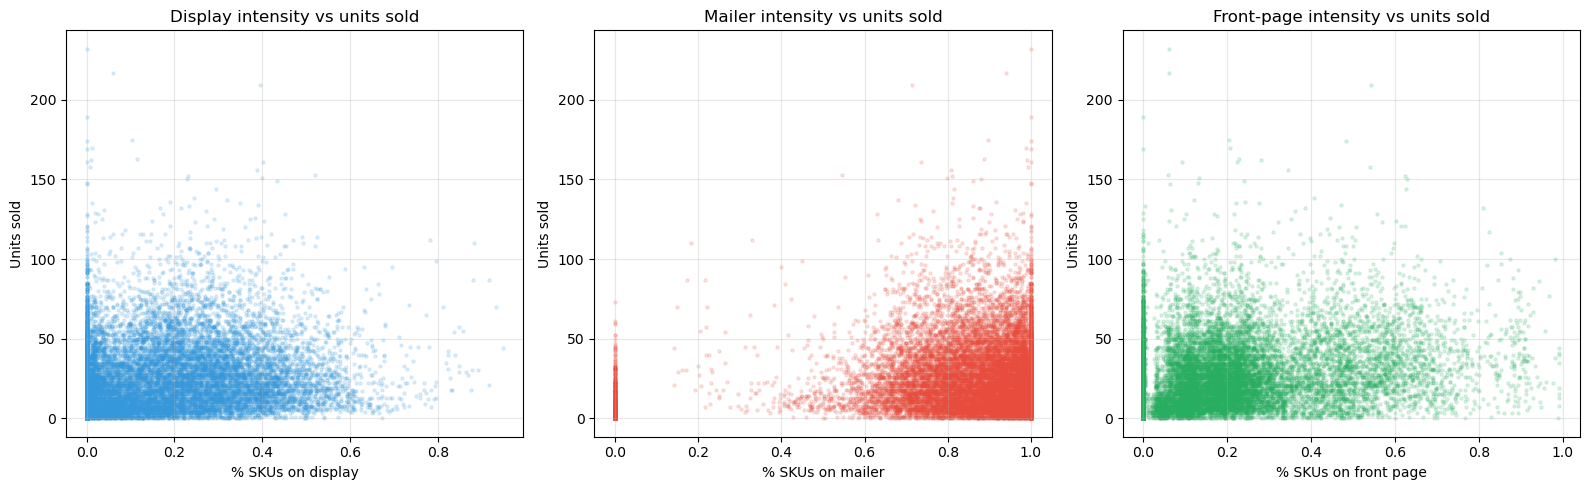

Pearson correlation with units_sold:
  pct_skus_on_display:    0.142
  pct_skus_on_mailer:     0.093
  pct_skus_front_page:    0.275


In [92]:
import matplotlib.pyplot as plt

dense_check = pd.read_parquet(DATA_INTERIM / "features_dense.parquet")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Display intensity vs sales
ax = axes[0]
ax.scatter(dense_check["pct_skus_on_display"], dense_check["units_sold"],
           alpha=0.15, s=5, c="#3498db")
ax.set_xlabel("% SKUs on display")
ax.set_ylabel("Units sold")
ax.set_title("Display intensity vs units sold")
ax.grid(alpha=0.3)

# 2. Mailer intensity vs sales
ax = axes[1]
ax.scatter(dense_check["pct_skus_on_mailer"], dense_check["units_sold"],
           alpha=0.15, s=5, c="#e74c3c")
ax.set_xlabel("% SKUs on mailer")
ax.set_ylabel("Units sold")
ax.set_title("Mailer intensity vs units sold")
ax.grid(alpha=0.3)

# 3. Front-page intensity vs sales
ax = axes[2]
ax.scatter(dense_check["pct_skus_front_page"], dense_check["units_sold"],
           alpha=0.15, s=5, c="#27ae60")
ax.set_xlabel("% SKUs on front page")
ax.set_ylabel("Units sold")
ax.set_title("Front-page intensity vs units sold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "promotion_vs_sales.png", dpi=100, bbox_inches="tight")
plt.show()

# Quick correlation numbers
print("Pearson correlation with units_sold:")
print(f"  pct_skus_on_display:    {dense_check[['pct_skus_on_display', 'units_sold']].corr().iloc[0,1]:.3f}")
print(f"  pct_skus_on_mailer:     {dense_check[['pct_skus_on_mailer', 'units_sold']].corr().iloc[0,1]:.3f}")
print(f"  pct_skus_front_page:    {dense_check[['pct_skus_front_page', 'units_sold']].corr().iloc[0,1]:.3f}")

### Cell 9 — Add lag features on promotional intensity

Last week's promotions can affect this week's sales (demand pull-forward, residual visibility). Add 1-week lags for the three promotion features. Same shift(1) discipline as before — no leakage.

In [93]:
# Reload from disk to start from clean saved state
dense = pd.read_parquet(DATA_INTERIM / "features_dense.parquet")
chain = pd.read_parquet(DATA_INTERIM / "features_chain.parquet")

PROMO_COLS = ["pct_skus_on_display", "pct_skus_on_mailer", "pct_skus_front_page"]

# Add 1-week lags for promotion features (dense grid)
dense = dense.sort_values(["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"]).copy()
for col in PROMO_COLS:
    dense[f"{col}_lag_1"] = dense.groupby(["STORE_ID", "PERISHABLE_CATEGORY"])[col].shift(1)
    dense[f"{col}_lag_1"] = dense[f"{col}_lag_1"].fillna(0)

# Add 1-week lags for promotion features (chain grid)
chain = chain.sort_values(["PERISHABLE_CATEGORY", "WEEK_START"]).copy()
for col in PROMO_COLS:
    chain[f"{col}_lag_1"] = chain.groupby("PERISHABLE_CATEGORY")[col].shift(1)
    chain[f"{col}_lag_1"] = chain[f"{col}_lag_1"].fillna(0)

print(f"Added 3 promotional lag features.")
print(f"Dense grid: {dense.shape[1]} columns")
print(f"Chain grid: {chain.shape[1]} columns")

Added 3 promotional lag features.
Dense grid: 35 columns
Chain grid: 34 columns


### Cell 10 — Add price features

Price changes drive demand. Add: lag of last week's average price, % change from last week, and current price vs 4-week rolling average (this last one detects markdowns and price hikes).

In [94]:
import numpy as np

PRICE_CLIP_RANGE = (-1.0, 5.0)  # -100% to +500% — anything beyond is a divide-by-zero artifact


def add_price_features(df, group_cols, price_col="avg_unit_price"):
    df = df.sort_values(group_cols + ["WEEK_START"]).copy()

    # 1-week lag of price
    df["price_lag_1"] = df.groupby(group_cols)[price_col].shift(1)

    # Week-over-week % change (clipped to remove divide-by-near-zero artifacts)
    df["price_change_pct"] = (df[price_col] - df["price_lag_1"]) / df["price_lag_1"].replace(0, np.nan)
    df["price_change_pct"] = df["price_change_pct"].clip(*PRICE_CLIP_RANGE)

    # Current price vs 4-week rolling average
    shifted_price = df.groupby(group_cols)[price_col].shift(1)
    df["price_roll_mean_4"] = (
        shifted_price.groupby([df[c] for c in group_cols])
        .transform(lambda x: x.rolling(4, min_periods=1).mean())
    )
    df["price_vs_4w_avg"] = (df[price_col] - df["price_roll_mean_4"]) / df["price_roll_mean_4"].replace(0, np.nan)
    df["price_vs_4w_avg"] = df["price_vs_4w_avg"].clip(*PRICE_CLIP_RANGE)

    return df


# Apply to dense grid
dense = add_price_features(dense, group_cols=["STORE_ID", "PERISHABLE_CATEGORY"])

# Chain grid: ensure avg_unit_price exists, then apply
if "avg_unit_price" not in chain.columns:
    chain["avg_unit_price"] = chain["sales_value"] / chain["units_sold"].replace(0, np.nan)
chain = add_price_features(chain, group_cols=["PERISHABLE_CATEGORY"])

# Fill remaining NaN values (price features can't be computed for first week of each series)
price_cols = ["price_lag_1", "price_change_pct", "price_roll_mean_4", "price_vs_4w_avg"]
for col in price_cols:
    dense[col] = dense[col].fillna(0)
    chain[col] = chain[col].fillna(0)

print(f"Added 4 price features (clipped to ±500% to remove artifacts).")
print(f"Dense grid: {dense.shape[1]} columns")
print(f"Chain grid: {chain.shape[1]} columns")
print(f"\nSample (dense):")
print(dense[["WEEK_START", "avg_unit_price", "price_lag_1", "price_change_pct", "price_vs_4w_avg"]].head(10).round(3).to_string(index=False))
print(f"\nValue ranges (should be within ±500% = [-1.0, 5.0]):")
print(f"  price_change_pct: [{dense['price_change_pct'].min():.3f}, {dense['price_change_pct'].max():.3f}]")
print(f"  price_vs_4w_avg:  [{dense['price_vs_4w_avg'].min():.3f}, {dense['price_vs_4w_avg'].max():.3f}]")

Added 4 price features (clipped to ±500% to remove artifacts).
Dense grid: 39 columns
Chain grid: 39 columns

Sample (dense):
WEEK_START  avg_unit_price  price_lag_1  price_change_pct  price_vs_4w_avg
2015-03-30           1.698        0.000             0.000            0.000
2015-04-06           1.490        1.698            -0.122           -0.122
2015-04-13           2.065        1.490             0.386            0.295
2015-04-20           1.997        2.065            -0.033            0.141
2015-04-27           2.118        1.997             0.060            0.168
2015-05-04           1.212        2.118            -0.428           -0.368
2015-05-11           1.519        1.212             0.253           -0.178
2015-05-18           1.053        1.519            -0.307           -0.385
2015-05-25           2.500        1.053             1.374            0.695
2015-06-01           1.638        2.500            -0.345            0.043

Value ranges (should be within ±500% = [-1.0, 5.

### Cell 11 — Validate new features have signal

Check correlation between new features and units_sold. Confirms whether they're worth including before training.

In [95]:
NEW_FEATURES = [
    "pct_skus_on_display_lag_1",
    "pct_skus_on_mailer_lag_1",
    "pct_skus_front_page_lag_1",
    "price_lag_1",
    "price_change_pct",
    "price_vs_4w_avg",
]

print("Pearson correlations with units_sold:")
print("=" * 50)
for feat in NEW_FEATURES:
    corr = dense[[feat, "units_sold"]].corr().iloc[0, 1]
    marker = "✓" if abs(corr) >= 0.05 else "  (weak)"
    print(f"  {feat:<35s} {corr:+.3f}  {marker}")

Pearson correlations with units_sold:
  pct_skus_on_display_lag_1           +0.129  ✓
  pct_skus_on_mailer_lag_1            -0.000    (weak)
  pct_skus_front_page_lag_1           +0.265  ✓
  price_lag_1                         -0.223  ✓
  price_change_pct                    -0.070  ✓
  price_vs_4w_avg                     -0.041    (weak)


### Cell 12 — Save final feature tables (overwrite previous)

These are the modeling-ready feature tables. Step 4 (model training) will load these.

In [96]:
dense.to_parquet(DATA_INTERIM / "features_dense.parquet", index=False)
chain.to_parquet(DATA_INTERIM / "features_chain.parquet", index=False)

print(f"Saved feature tables:")
print(f"  features_dense.parquet — {dense.shape[0]:,} rows × {dense.shape[1]} columns")
print(f"  features_chain.parquet — {chain.shape[0]:,} rows × {chain.shape[1]} columns")

print(f"\nFinal feature column list:")
non_meta = [c for c in dense.columns if c not in ["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START", "units_sold", "sales_value", "n_baskets", "avg_unit_price", "n_unique_skus", "YEAR", "MONTH", "WEEK_OF_YEAR", "QUARTER"]]
print(f"  Total features for model: {len(non_meta)}")
for f in non_meta:
    print(f"    • {f}")

Saved feature tables:
  features_dense.parquet — 15,694 rows × 39 columns
  features_chain.parquet — 76 rows × 39 columns

Final feature column list:
  Total features for model: 27
    • units_lag_1
    • units_lag_2
    • units_lag_4
    • units_lag_8
    • units_lag_52
    • units_roll_mean_4
    • units_roll_std_4
    • units_roll_mean_12
    • units_roll_std_12
    • WEEKS_TO_YEAR_END
    • WEEKS_TO_CHRISTMAS
    • CAT_BAKERY
    • CAT_DAIRY
    • CAT_DELI
    • CAT_MEAT
    • CAT_PRODUCE
    • CAT_SEAFOOD
    • pct_skus_on_display
    • pct_skus_on_mailer
    • pct_skus_front_page
    • pct_skus_on_display_lag_1
    • pct_skus_on_mailer_lag_1
    • pct_skus_front_page_lag_1
    • price_lag_1
    • price_change_pct
    • price_roll_mean_4
    • price_vs_4w_avg


### Cell 13 — Sanity check feature tables before training

Trust-but-verify pass. Confirms column counts, no NaN/inf values, no zero-variance features, and reasonable data ranges. Catches bugs before they waste model training time.

In [97]:
import numpy as np

def audit_features(df, name, group_cols):
    print(f"\n{'='*60}")
    print(f"AUDIT: {name}")
    print(f"{'='*60}")

    # Basic shape
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # Identify feature columns (exclude metadata and target)
    meta_cols = ["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START", "YEAR",
                 "MONTH", "WEEK_OF_YEAR", "QUARTER", "units_sold", "sales_value",
                 "n_baskets", "avg_unit_price", "n_unique_skus", "n_active_stores"]
    feature_cols = [c for c in df.columns if c not in meta_cols]
    print(f"Feature columns: {len(feature_cols)}")

    # Check 1: NaN values in features
    nan_counts = df[feature_cols].isnull().sum()
    nan_features = nan_counts[nan_counts > 0]
    if len(nan_features) > 0:
        print(f"\n⚠️  NaN values found in features:")
        print(nan_features.to_string())
    else:
        print(f"\n✓ No NaN values in features")

    # Check 2: Infinite values
    numeric_features = df[feature_cols].select_dtypes(include=[np.number])
    inf_counts = np.isinf(numeric_features).sum()
    inf_features = inf_counts[inf_counts > 0]
    if len(inf_features) > 0:
        print(f"\n⚠️  Infinite values found:")
        print(inf_features.to_string())
    else:
        print(f"✓ No infinite values")

    # Check 3: Zero-variance features (useless to model)
    variances = numeric_features.var()
    zero_var = variances[variances == 0]
    if len(zero_var) > 0:
        print(f"\n⚠️  Zero-variance features (constant, useless):")
        print(zero_var.to_string())
    else:
        print(f"✓ No zero-variance features")

    # Check 4: Suspicious ranges
    print(f"\nFeature value ranges (showing min/max for sanity):")
    for col in ["units_sold", "units_lag_1", "units_roll_mean_4",
                "pct_skus_on_display", "pct_skus_on_mailer",
                "price_change_pct", "price_vs_4w_avg"]:
        if col in df.columns:
            mn, mx = df[col].min(), df[col].max()
            print(f"  {col:<30s} [{mn:>10.3f}, {mx:>10.3f}]")

    # Check 5: Rows per series
    series_counts = df.groupby(group_cols).size()
    print(f"\nWeeks per series:")
    print(f"  Min:    {series_counts.min()}")
    print(f"  Median: {series_counts.median():.0f}")
    print(f"  Max:    {series_counts.max()}")

    # Check 6: Target variable health
    print(f"\nTarget variable (units_sold):")
    print(f"  Zero-sales rows: {(df['units_sold'] == 0).sum():,} ({(df['units_sold'] == 0).mean()*100:.1f}%)")
    print(f"  Mean: {df['units_sold'].mean():.1f}")
    print(f"  Median: {df['units_sold'].median():.0f}")

    return len(feature_cols)


n_dense_features = audit_features(dense, "DENSE GRID", ["STORE_ID", "PERISHABLE_CATEGORY"])
n_chain_features = audit_features(chain, "CHAIN GRID", ["PERISHABLE_CATEGORY"])

print(f"\n{'='*60}")
print(f"VERDICT")
print(f"{'='*60}")
print(f"Dense feature count: {n_dense_features}")
print(f"Chain feature count: {n_chain_features}")
print(f"\nIf both have same feature count, no warnings printed above, and")
print(f"value ranges look reasonable — we're ready for model training.")


AUDIT: DENSE GRID
Shape: 15,694 rows × 39 columns
Feature columns: 27

✓ No NaN values in features
✓ No infinite values

⚠️  Zero-variance features (constant, useless):
CAT_BAKERY     0.0
CAT_SEAFOOD    0.0

Feature value ranges (showing min/max for sanity):
  units_sold                     [     0.000,    232.000]
  units_lag_1                    [     0.000,    232.000]
  units_roll_mean_4              [     0.000,    175.500]
  pct_skus_on_display            [     0.000,      0.947]
  pct_skus_on_mailer             [     0.000,      1.000]
  price_change_pct               [    -0.997,      5.000]
  price_vs_4w_avg                [    -0.997,      5.000]

Weeks per series:
  Min:    38
  Median: 38
  Max:    38

Target variable (units_sold):
  Zero-sales rows: 392 (2.5%)
  Mean: 25.6
  Median: 20

AUDIT: CHAIN GRID
Shape: 76 rows × 39 columns
Feature columns: 27

✓ No NaN values in features
✓ No infinite values

⚠️  Zero-variance features (constant, useless):
CAT_DAIRY      0.0
CAT_